# Watermark Predictor Benchmark Results

Plots for `results/results.csv`. Hue is always the `predictor`. VLDB/SIGMOD-style figures.

Run `pip install pandas matplotlib seaborn` if not already available.

## Reading the `trace` labels

Each trace is a synthetic watermark stream — a sequence of `(watermark value, wall-clock arrival)` **samples**. Evaluation is **rolling / prequential**: a warm-up prefix is batch-observed, then every later sample is observed online and immediately queried at each horizon. A label combines a base regime with optional noise.

**Base regime** (the clean signal — deterministic, no randomness):
- `ConstantRate(2.0)` — single phase, watermark advances at a fixed rate the whole time.
- `Stall(2.0->0)` — the watermark **holds flat** (rate 0) while wall-clock keeps advancing, then resumes. Models an idle source / event-time gap.
- `CatchUp(2.0->8.0)` — a short stall, then a **fast burst** (rate 8.0) that drains the backlog, then settles back to rate 2.0. Breaks predictors that carry the stalled rate forward *and* ones that overshoot on the burst.

**Noise tags** — perturb only the *wall-clock arrival* of each sample; the watermark values themselves are untouched:
- `clean` — no noise.
- `mild/heavy jitter (sd=σ)` — zero-mean Gaussian jitter on arrivals (σ = 10 / 30). Symmetric.
- `X% stragglers` — a fraction `X` of samples get an extra one-sided delay (heavy positive tail), on top of light jitter.

**Two independent axes** the plots use (no more `+N samples` tag — the rolling eval gives both for free):
- `eval_offset` — *when* the prediction was made: samples since warm-up ended (`0` = the regime onset for event traces).
- `horizon` — *how far ahead* it forecast: event-time look-ahead added to the last watermark (think window size).

**Saturation.** During a stall the target watermark isn't reached until the stream resumes, so a predictor extrapolating a ~0 rate returns the "never reaches" ceiling (`abs_err ≈ 5e15`). Those points are flagged `saturated` and excluded from the robust metrics (median abs error, max *real* error); the **saturation fraction** reports how often each predictor gave up instead.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

# results.csv is LONG now: one row per scored prediction from the rolling (prequential) evaluation.
#   eval_offset    = samples since warm-up ended (0 = first online prediction; the regime onset for event traces)
#   horizon        = event-time look-ahead of the query (think window size)
#   abs_err        = |predicted - true| wall-clock
#   signed_err     = predicted - true wall-clock (sign = early / late)
#   true_wall      = ground-truth crossing wall-clock (percentage-error denominator)
#   ns_per_predict = per-predict latency for the cell, denormalised onto every row
df = pd.read_csv(Path('results') / 'results.csv')

# --- parse the trace string into structured scenario columns ------------
def family(t):
    if t.startswith('ConstantRate'):
        return 'ConstantRate'
    if t.startswith('Stall'):
        return 'Stall'
    if t.startswith('CatchUp'):
        return 'CatchUp'
    return 'Other'

def noise(t):
    if 'heavy jitter' in t:
        return 'heavy jitter'
    if 'mild jitter' in t:
        return 'mild jitter'
    if 'heavy stragglers' in t:
        return 'heavy stragglers'
    if 'stragglers' in t:
        return 'stragglers'
    return 'clean'

def grab(pattern, t, cast=float):
    m = re.search(pattern, t)
    return cast(m.group(1)) if m else None

df['family'] = df['trace'].map(family)
df['noise'] = df['trace'].map(noise)
df['straggler_pct'] = df['trace'].apply(lambda t: grab(r'(\d+)% ', t, int))   # heavy-straggler fraction
df['jitter_sd'] = df['trace'].apply(lambda t: grab(r'sd=(\d+)', t, int))       # jitter standard deviation

# During a stall the target watermark isn't reached until the stream resumes, so a predictor that
# extrapolates a ~0 rate returns the saturated "never" wall-clock (Timestamp::INVALID_VALUE-1 ≈ 5e15).
# Those points aren't real error — they swamp any mean AND any percentage error. Flag them and report
# ROBUST stats: median abs error (mdae) and median abs % error (mdape, scale-free) both ignore the
# ceiling, and sat_rate ("how often did the predictor give up?") is the honest companion.
SAT = 1e9  # abs_err at/above this is the saturation ceiling, not a real miss (real errors are < ~1e6)
df['saturated'] = df['abs_err'] >= SAT

# --- aggregate the long frame to one metrics row per (trace, predictor) -----
# Headline accuracy views (boxplots, heatmap, latency, sweeps) use `cell`; the rolling/horizon
# curves use the long `df` directly.
def _agg(g):
    ae, se, tw, sat = g['abs_err'], g['signed_err'], g['true_wall'], g['saturated']
    pos = tw > 0
    unsat = ~sat
    real = unsat & pos                 # non-saturated, positive-truth -> valid for a percentage error
    return pd.Series({
        'mae': ae.mean(),                                        # mean abs err (saturation-dominated for stalls)
        'mdae': ae.median(),                                     # median abs err — robust to the ceiling
        'rmse': np.sqrt((se ** 2).mean()),
        'mape_pct': (ae[pos] / tw[pos] * 100).mean() if pos.any() else np.nan,        # mean % (saturation-dominated)
        'mdape_pct': (ae[real] / tw[real] * 100).median() if real.any() else np.nan,  # median % — robust, scale-free
        'max_err': ae[unsat].max() if unsat.any() else np.nan,   # worst REAL error (ignores the ceiling)
        'sat_rate': sat.mean(),                                  # fraction that hit the "never reaches" ceiling
        'samples': len(g),
        'ns_per_predict': g['ns_per_predict'].iloc[0],
    })

cell = (df.groupby(['trace', 'predictor'], sort=False)[['abs_err', 'signed_err', 'true_wall', 'saturated', 'ns_per_predict']]
          .apply(_agg).reset_index())
for col in ['family', 'noise', 'straggler_pct', 'jitter_sd']:
    cell[col] = cell['trace'].map(df.drop_duplicates('trace').set_index('trace')[col])

PREDICTOR_ORDER = sorted(df['predictor'].unique())
print('long rows:', df.shape, '| cells:', cell.shape, '| predictors:', list(df['predictor'].unique()))
cell.head()

long rows: (46800, 13) | cells: (84, 15) | predictors: ['EWMA(alpha=0.3)', 'EWMA(alpha=0.5)', 'EWMA(alpha=1.0)', 'Kalman(stable)', 'Kalman(reactive)', 'RobustAdaptiveKalman']


,trace,predictor,mae,mdae,rmse,mape_pct,mdape_pct,max_err,sat_rate,samples,ns_per_predict,family,noise,straggler_pct,jitter_sd
0,ConstantRate(2.0) clean,EWMA(alpha=0.3),0.000000,0.0,0.000000,0.00000,0.000000,0.0,0.0,525.0,4.567,ConstantRate,clean,NaN,NaN
1,ConstantRate(2.0) clean,EWMA(alpha=0.5),0.000000,0.0,0.000000,0.00000,0.000000,0.0,0.0,525.0,4.546,ConstantRate,clean,NaN,NaN
2,ConstantRate(2.0) clean,EWMA(alpha=1.0),0.000000,0.0,0.000000,0.00000,0.000000,0.0,0.0,525.0,4.543,ConstantRate,clean,NaN,NaN
3,ConstantRate(2.0) clean,Kalman(stable),0.000000,0.0,0.000000,0.00000,0.000000,0.0,0.0,525.0,4.651,ConstantRate,clean,NaN,NaN
4,ConstantRate(2.0) clean,Kalman(reactive),0.702857,1.0,0.838366,0.00661,0.007519,1.0,0.0,525.0,4.651,ConstantRate,clean,NaN,NaN


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# VLDB / SIGMOD camera-ready style: serif, compact, no chartjunk.
sns.set_theme(context='paper', style='whitegrid', font='serif')
plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 11,
    'axes.labelsize': 11,
    'axes.titleweight': 'bold',
    'legend.fontsize': 9,
    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.4,
})
# tab10 = the most-separated qualitative hues; the muted 'colorblind' set washed out the
# same-family predictors (3x EWMA, 2x Kalman, Robust). MARKERS adds a second visual channel so
# the line plots stay readable where two hues sit close — pass them via style= in lineplot.
PALETTE = dict(zip(PREDICTOR_ORDER, sns.color_palette('tab10', len(PREDICTOR_ORDER))))
MARKERS = dict(zip(PREDICTOR_ORDER, ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>'][:len(PREDICTOR_ORDER)]))

def legend_below(ax, ncol=None):
    ax.legend(title='predictor', loc='upper center', bbox_to_anchor=(0.5, -0.18),
              ncol=ncol or len(PREDICTOR_ORDER))

def legend_top(fig, src, title=None, ncol=3, pad=0.012):
    """Put the predictor legend in a horizontal strip between the title and the axes.
    Owns the whole top band — pass the figure title here (don't call fig.suptitle separately) and do
    NOT use tight_layout / constrained layout (constrained can't stack a suptitle above an outside
    figure legend, so we measure the legend and reserve space by hand). `src` is the axes to pull
    handles from, or an explicit (handles, labels) pair. Per-axes titles get their own gap so a
    top-row ax.set_title doesn't collide with the legend."""
    if hasattr(src, 'get_legend_handles_labels'):
        handles, labels = src.get_legend_handles_labels()
        if src.get_legend():
            src.get_legend().remove()
    else:
        handles, labels = src
    fig.canvas.draw()  # need a renderer to measure the legend height
    leg = fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.0),
                     ncol=ncol, frameon=False, fontsize=9)
    fig.canvas.draw()
    lh = leg.get_window_extent().transformed(fig.transFigure.inverted()).height
    st_h = 0.05 if title else 0.0
    ath = 0.05 if any(ax.get_title() for ax in fig.axes) else 0.0   # gap for top-row ax titles
    top = 1.0 - lh - st_h - ath - 2 * pad
    fig.subplots_adjust(top=top)
    leg.set_bbox_to_anchor((0.5, 1.0 - st_h - pad), transform=fig.transFigure)  # legend top under title
    if title:
        fig.suptitle(title, y=1.0 - pad, va='top')
print('style ready, palette:', PALETTE)

style ready, palette: {'EWMA(alpha=0.3)': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 'EWMA(alpha=0.5)': (1.0, 0.4980392156862745, 0.054901960784313725), 'EWMA(alpha=1.0)': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313), 'Kalman(reactive)': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392), 'Kalman(stable)': (0.5803921568627451, 0.403921568627451, 0.7411764705882353), 'RobustAdaptiveKalman': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354)}


## 0. Scenario shapes
The raw signal each predictor must extrapolate: watermark **event-time** against **wall-clock** for every clean base scenario. Slope = advancement rate, flat = stall, steep = catch-up burst. Exported by the benchmark binary to `results/traces.csv` (single source of truth — same definitions the accuracy runs use).

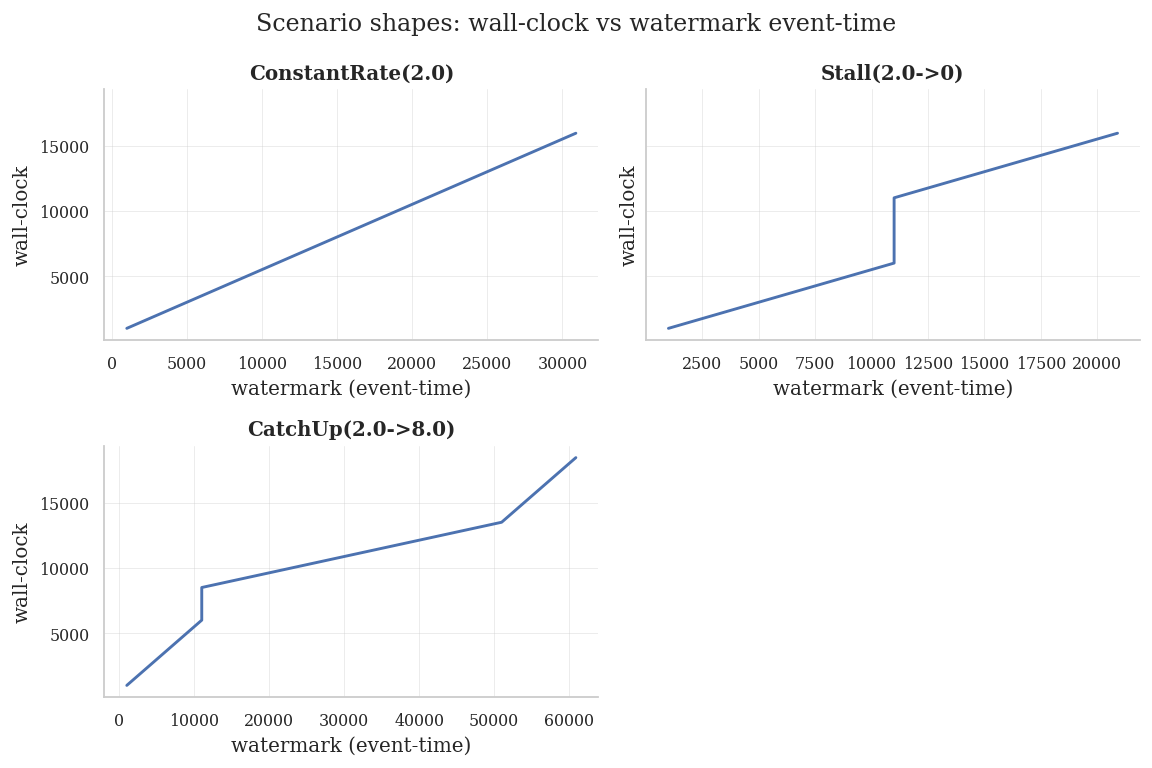

In [3]:
traces = pd.read_csv(Path('results') / 'traces.csv')
scenarios = list(traces['scenario'].unique())
ncol = 2
nrow = -(-len(scenarios) // ncol)  # ceil
fig, axes = plt.subplots(nrow, ncol, figsize=(9, 3.0 * nrow), sharey=True)
for ax, scen in zip(axes.flat, scenarios):
    g = traces[traces['scenario'] == scen]
    ax.plot(g['event_time'], g['wall_clock'], lw=1.6, color='C0')
    ax.set_title(scen)
    ax.set_xlabel('watermark (event-time)')
    ax.set_ylabel('wall-clock')
for ax in axes.flat[len(scenarios):]:
    ax.set_visible(False)
fig.suptitle('Scenario shapes: wall-clock vs watermark event-time')
fig.tight_layout()
plt.show()

## 1. Accuracy per scenario family
**Median** absolute error (robust to the stall "never reaches" saturation that swamps the mean) and the **saturation fraction** — how often each predictor gave up and returned the ceiling. MdAE = real accuracy when a finite answer is produced; sat-rate = how often it isn't.

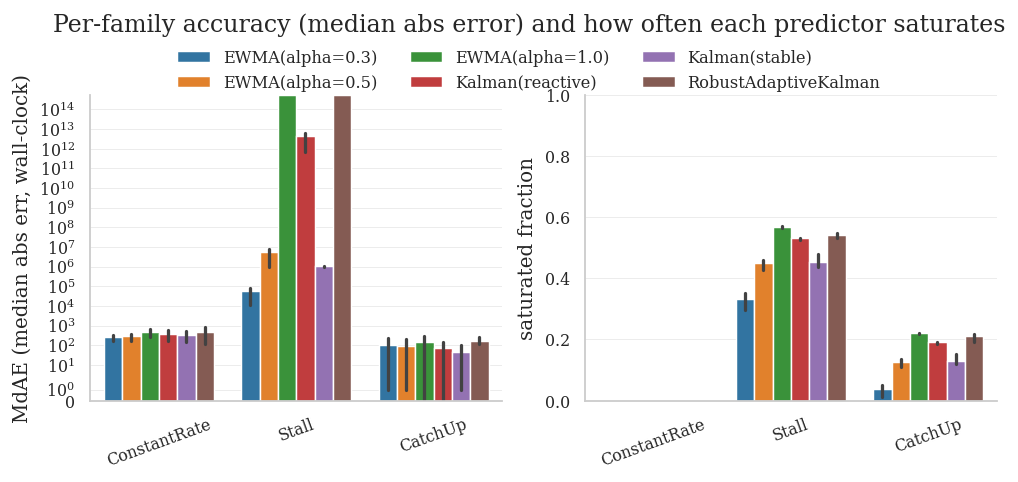

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharex=True)
# left: median abs error (symlog because clean families are exactly 0; bottom=0 drops the negative
# half-axis). right: saturation fraction (linear 0..1).
for ax, (metric, label, logscale) in zip(
        axes, [('mdae', 'MdAE (median abs err, wall-clock)', True), ('sat_rate', 'saturated fraction', False)]):
    sns.barplot(cell, x='family', y=metric, hue='predictor', hue_order=PREDICTOR_ORDER,
                palette=PALETTE, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel(label)
    if logscale:
        ax.set_yscale('symlog')
        ax.set_ylim(bottom=0)
    ax.tick_params(axis='x', rotation=20)
    ax.get_legend().remove()
axes[1].set_ylim(0, 1)
legend_top(fig, axes[0], title='Per-family accuracy (median abs error) and how often each predictor saturates')
plt.show()

## 2. Rolling error after a stall / catch-up
The prequential view: prediction error at every step of the online phase, `eval_offset=0` being the regime onset (warm-up ends there). **Stall**: rate drops to 0 — does the predictor stop extrapolating forward? **CatchUp**: a stall, a rate-8 burst, then a settle back to rate 2.0 — does it track the surge *and* the return, or lag carrying the stalled/burst rate? Lines are the mean abs error over the three horizons; the spike-and-decay shape *is* the adaptation curve the old `+N` sweeps only sampled at a few points.

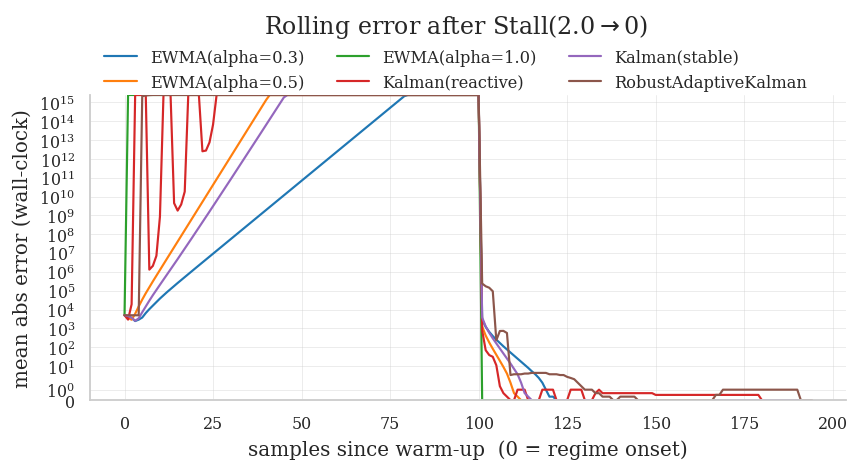

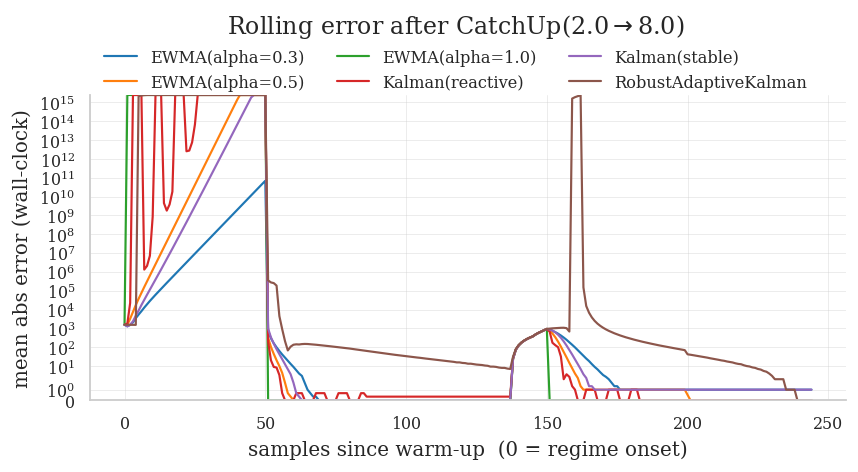

In [5]:
for fam, title in [('Stall', 'Stall(2.0$\\rightarrow$0)'), ('CatchUp', 'CatchUp(2.0$\\rightarrow$8.0)')]:
    sub = df[(df['family'] == fam) & (df['noise'] == 'clean')]
    fig, ax = plt.subplots(figsize=(7.5, 3.4))
    sns.lineplot(sub, x='eval_offset', y='abs_err', hue='predictor', hue_order=PREDICTOR_ORDER,
                 palette=PALETTE, errorbar=None, ax=ax)   # mean over horizons, no CI band
    ax.set_yscale('symlog')      # error returns to exactly 0 after recovery -> symlog, not log
    ax.set_ylim(bottom=0)        # drop the negative half-axis
    ax.set_xlabel('samples since warm-up  (0 = regime onset)')
    ax.set_ylabel('mean abs error (wall-clock)')
    legend_top(fig, ax, title=f'Rolling error after {title}')
    plt.show()

## 2b. Look-ahead sensitivity (error vs. horizon)
With the rolling eval owning the time axis, `horizon` is a clean second axis: does error grow as you forecast further ahead (bigger window)? A constant-velocity model with a slightly-off rate is fine near-term and drifts far-term, because rate error scales with look-ahead. Restricted to the **ConstantRate family** — it never saturates, so all predictors are scored on the same points (the jitter/straggler traces supply the rate error; clean contributes ~0).

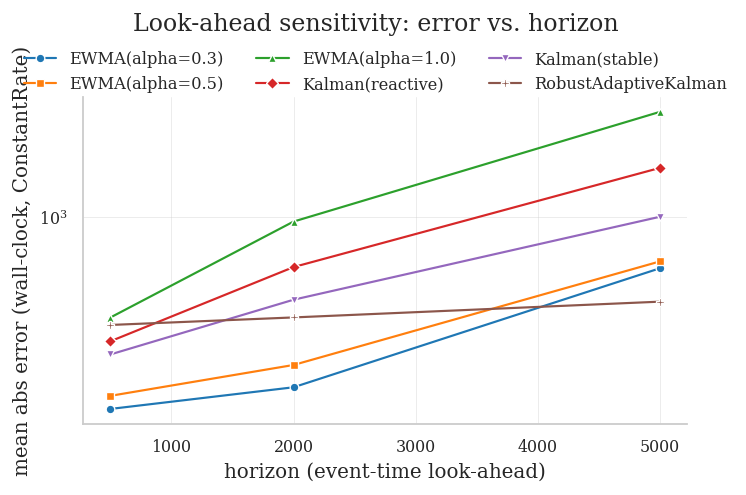

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.6))
# ConstantRate family only: it never saturates, so every predictor is compared on the SAME points
# (excluding saturated stall points instead would bias each predictor differently). Clean contributes
# ~0; the jitter/straggler traces supply the rate-estimate error that horizon amplifies.
look = df[df['family'] == 'ConstantRate']
sns.lineplot(look, x='horizon', y='abs_err', hue='predictor', hue_order=PREDICTOR_ORDER,
             style='predictor', markers=MARKERS, dashes=False, palette=PALETTE, errorbar=None, ax=ax)
ax.set_xlabel('horizon (event-time look-ahead)')
ax.set_ylabel('mean abs error (wall-clock, ConstantRate)')
ax.set_yscale('log')  # per-horizon mean is strictly positive -> plain log
legend_top(fig, ax, title='Look-ahead sensitivity: error vs. horizon')
plt.show()

## 3. Robustness to stragglers
Error as the fraction of heavy stragglers grows (ConstantRate(2.0) base). Tests how each predictor tolerates delayed/late samples.

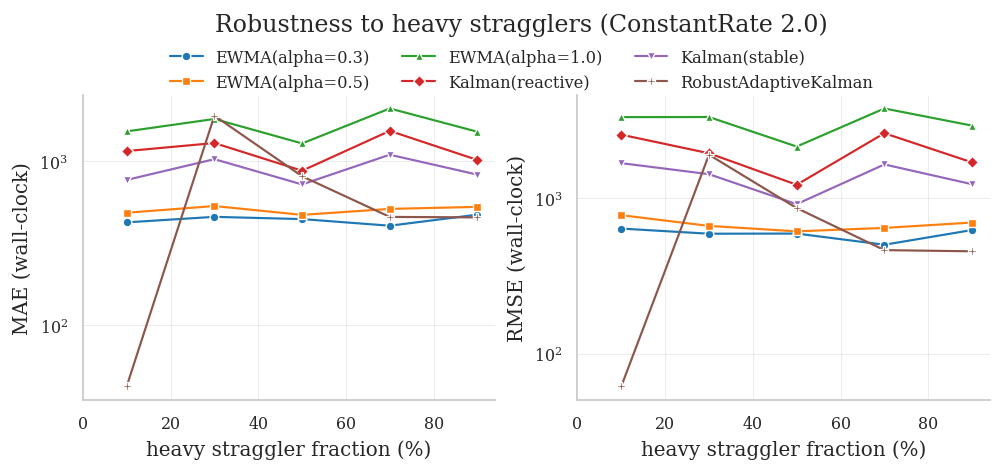

In [7]:
strag = cell[cell['straggler_pct'].notna() & (cell['family'] == 'ConstantRate')].copy()
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
for ax, (metric, label) in zip(axes, [('mae', 'MAE (wall-clock)'), ('rmse', 'RMSE (wall-clock)')]):
    sns.lineplot(strag, x='straggler_pct', y=metric, hue='predictor', hue_order=PREDICTOR_ORDER,
                 style='predictor', markers=MARKERS, dashes=False, palette=PALETTE, ax=ax)
    ax.set_xlabel('heavy straggler fraction (%)')
    ax.set_ylabel(label)
    ax.set_xlim(left=0)
    ax.set_yscale('log')  # strictly positive (no perfect predictions here) -> plain log
    ax.get_legend().remove()
legend_top(fig, axes[0], title='Robustness to heavy stragglers (ConstantRate 2.0)')
plt.show()

## 4. Sensitivity to jitter
Error grouped by jitter level (clean / mild sd=10 / heavy sd=30), one panel per scenario family that carries jitter (ConstantRate, Stall, CatchUp). **Top row — MdAE** (typical error): rewards predictors that keep emitting finite forecasts. **Bottom row — max real err** (worst-case, log): exposes the ones that carry the pre-stall rate forward and blow up toward the saturation ceiling. Read together — e.g. RobustAdaptiveKalman has a higher median on Stall but the lowest worst case, because it recognizes the stall early and stops over-forecasting.

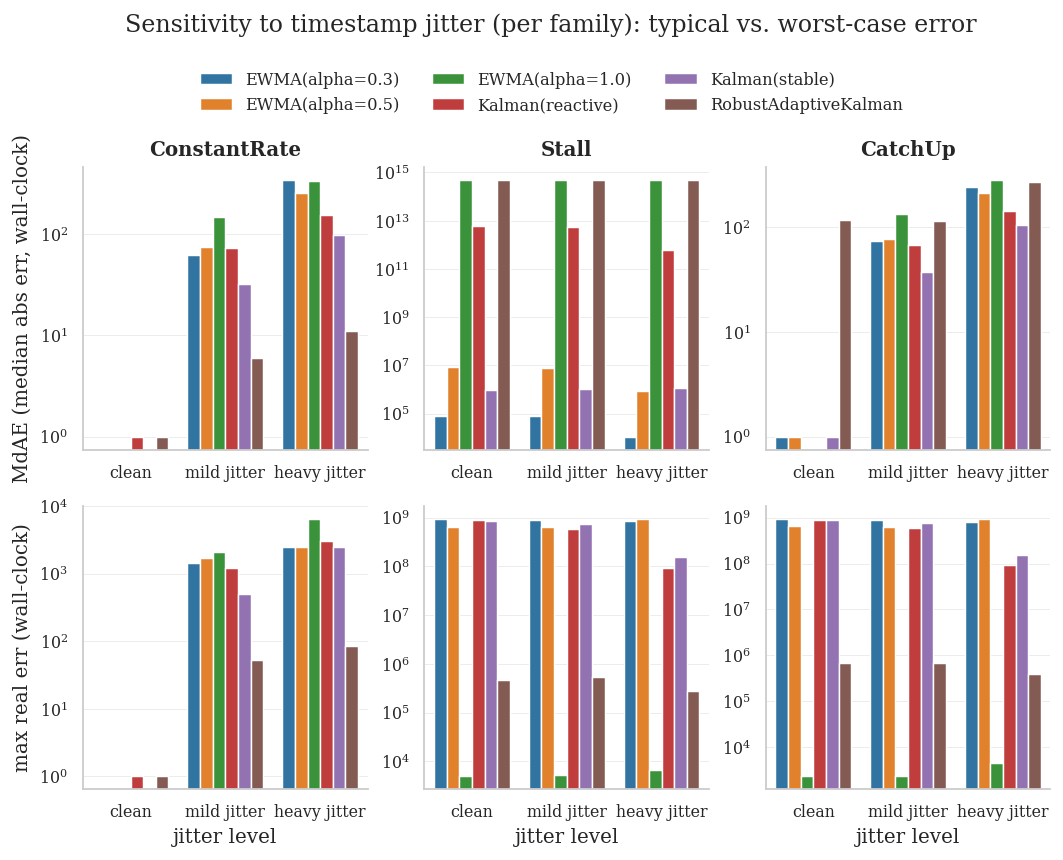

In [8]:
jit_order = ['clean', 'mild jitter', 'heavy jitter']
jit = cell[cell['noise'].isin(jit_order)].copy()   # every family that carries jitter, not just ConstantRate
jit['noise'] = pd.Categorical(jit['noise'], categories=jit_order, ordered=True)
fams = [f for f in ['ConstantRate', 'Stall', 'CatchUp'] if f in set(jit['family'])]
# Two rows: MdAE rewards predictors that delay giving up on a stall; max real err exposes the ones that
# carry the pre-stall rate forward and blow up. Together they're the honest "who handles jitter" view.
rows = [('mdae', 'MdAE (median abs err, wall-clock)'), ('max_err', 'max real err (wall-clock)')]
fig, axes = plt.subplots(len(rows), len(fams), figsize=(3.2 * len(fams), 3.4 * len(rows)), squeeze=False)
for r, (metric, ylabel) in enumerate(rows):
    for c, fam in enumerate(fams):
        ax = axes[r][c]
        sns.barplot(jit[jit['family'] == fam], x='noise', y=metric, hue='predictor',
                    hue_order=PREDICTOR_ORDER, palette=PALETTE, ax=ax)
        ax.set_xlabel('jitter level' if r == len(rows) - 1 else '')
        ax.set_ylabel(ylabel if c == 0 else '')
        ax.set_title(fam if r == 0 else '')
        ax.set_yscale('log')  # spans saturation-adjacent magnitudes -> log
        ax.get_legend().remove()
legend_top(fig, axes[0][0], title='Sensitivity to timestamp jitter (per family): typical vs. worst-case error')
plt.show()

## 5. Accuracy vs. latency trade-off
Per-predict cost (ns) against achieved error. Cheap *and* accurate is bottom-left. Marker per scenario family.

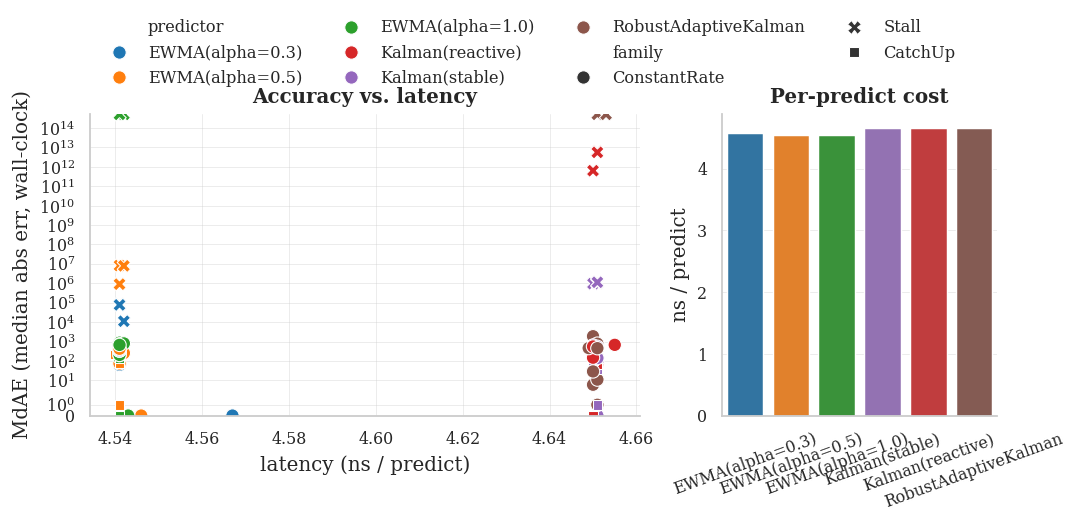

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), gridspec_kw={'width_ratios': [2, 1]})

# median abs err on y so the stall saturation cluster doesn't pin everything at the ceiling.
sns.scatterplot(cell, x='ns_per_predict', y='mdae', hue='predictor', hue_order=PREDICTOR_ORDER,
                style='family', palette=PALETTE, s=55, ax=axes[0])
axes[0].set_xlabel('latency (ns / predict)')
axes[0].set_ylabel('MdAE (median abs err, wall-clock)')
axes[0].set_yscale('symlog')      # clean families are exactly 0 -> symlog
axes[0].set_ylim(bottom=0)        # drop the negative half-axis
axes[0].set_title('Accuracy vs. latency')

# per-predict latency is constant per predictor (cell-level) -> one value each.
lat = cell.drop_duplicates('predictor')
sns.barplot(lat, x='predictor', y='ns_per_predict', hue='predictor', hue_order=PREDICTOR_ORDER,
            palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_xlabel('')
axes[1].set_ylabel('ns / predict')
axes[1].set_title('Per-predict cost')
axes[1].tick_params(axis='x', rotation=20)
# combined predictor+family legend (the scatter carries both channels) in the top strip.
legend_top(fig, axes[0], ncol=4)
plt.show()

## 6. Per-trace robust-metric heatmap
Every trace × predictor. **MdAE** (median abs error) and **MdAPE** (median abs % error — scale-free) show accuracy; **max real err** is the worst non-saturated miss; **sat frac** is how often the predictor returned the "never reaches" ceiling. All percentage/accuracy metrics exclude saturated points so the stall ceiling can't swamp them. Color is normalized per row; cyan outlines the per-row best.

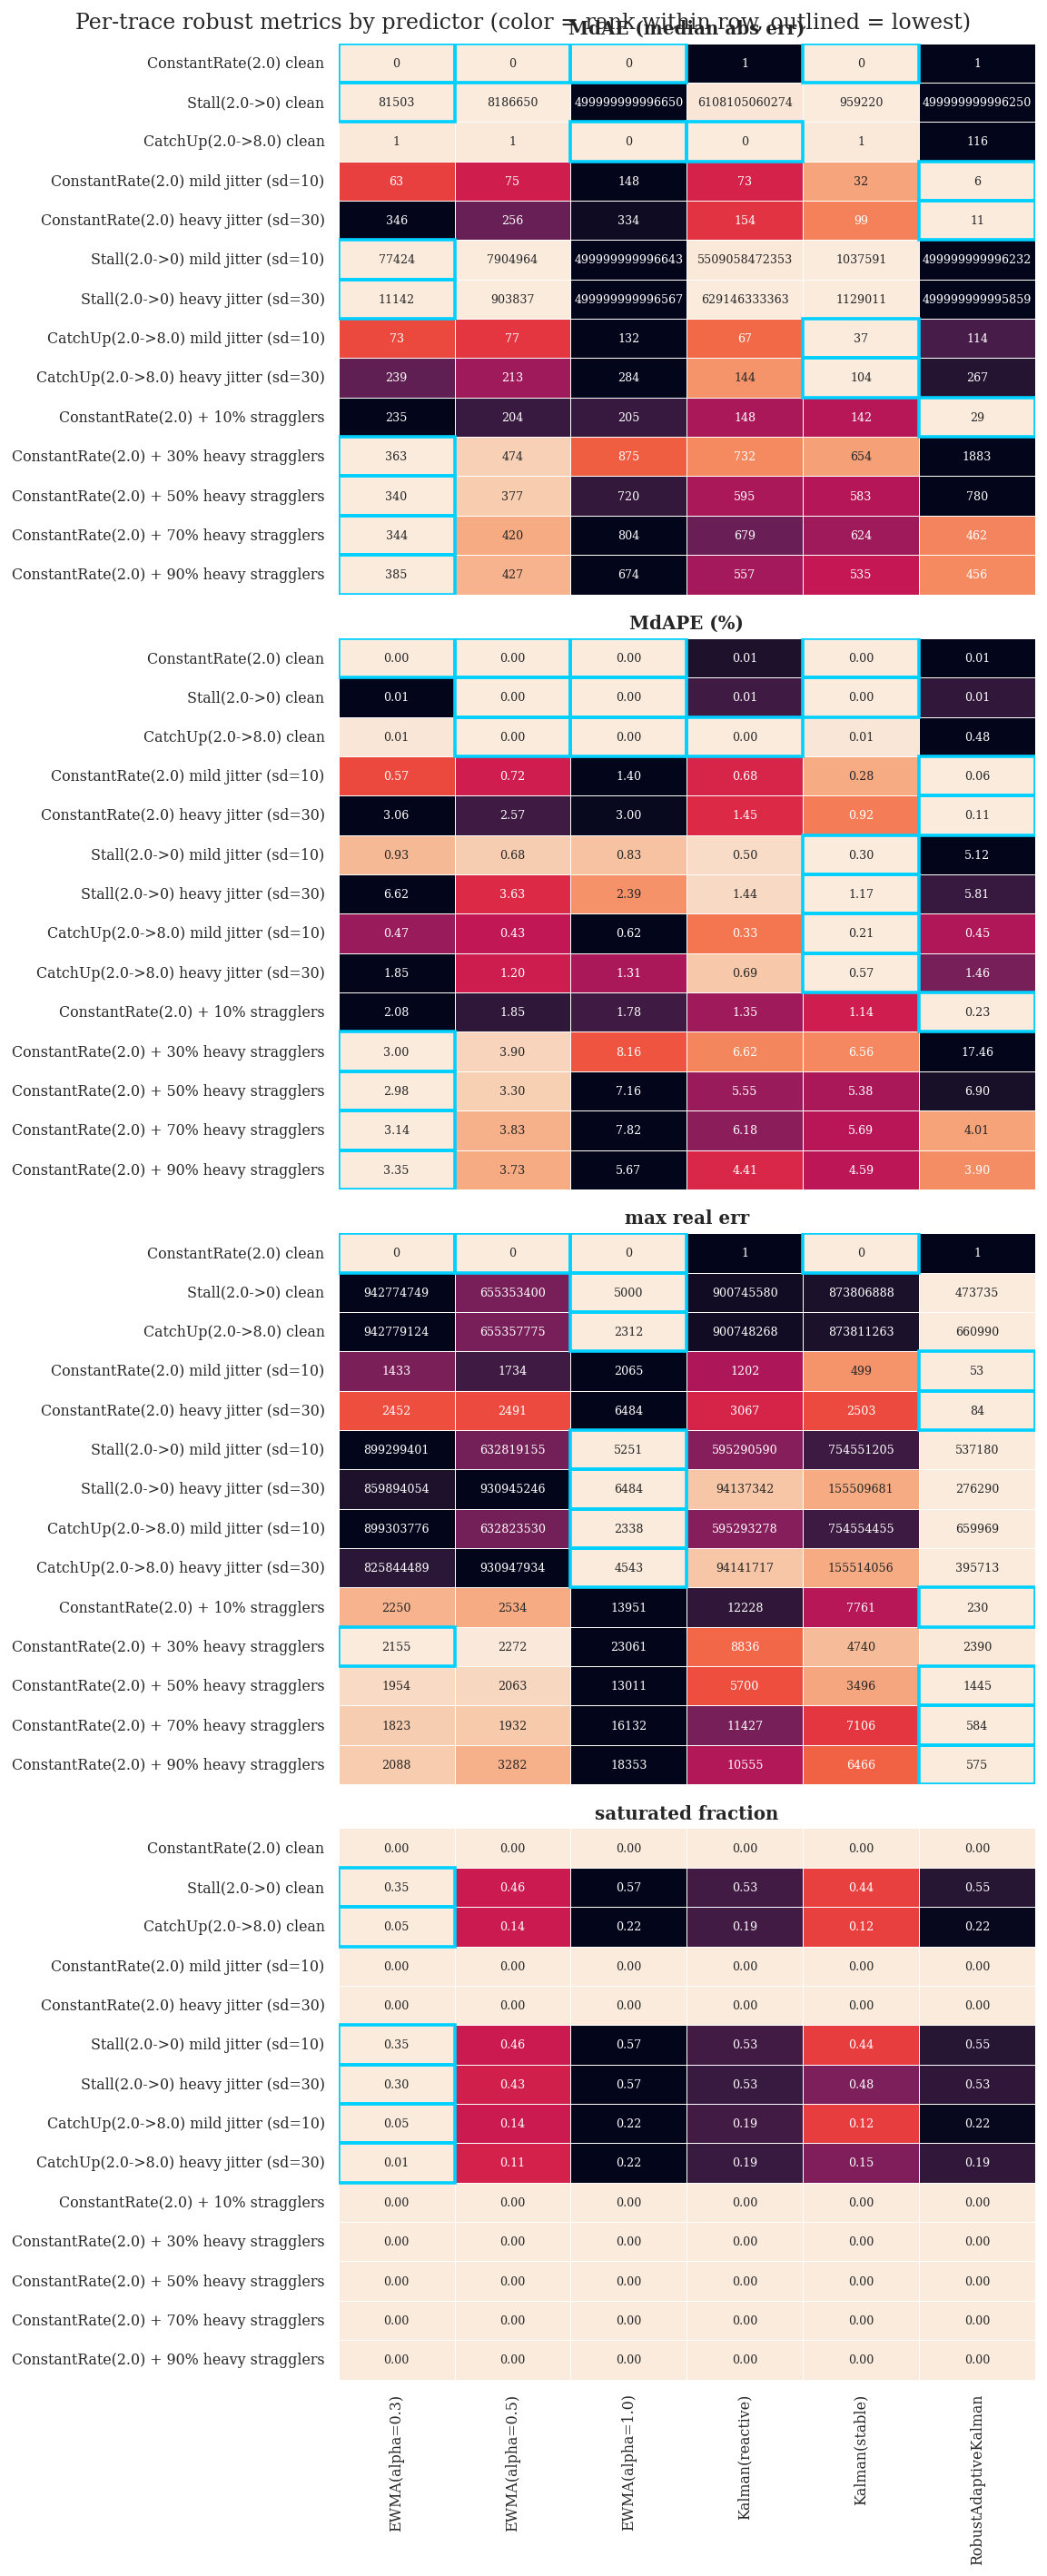

In [10]:
from matplotlib.patches import Rectangle

# per-trace x predictor heatmap on the robust metrics (all lower = better), from the aggregated cells.
# One metric per row, stacked vertically (shared predictor x-axis). MdAPE is the scale-free percentage
# view (median |err|/true over non-saturated points). Color is normalized PER ROW of each heatmap so a
# few huge-magnitude traces don't flatten the rest; cyan outlines the per-trace best.
METRICS = [('mdae', 'MdAE (median abs err)', '.0f'), ('mdape_pct', 'MdAPE (%)', '.2f'),
           ('max_err', 'max real err', '.0f'), ('sat_rate', 'saturated fraction', '.2f')]
ntraces = cell['trace'].nunique()
fig, axes = plt.subplots(len(METRICS), 1, figsize=(1.0 * len(PREDICTOR_ORDER) + 3, (0.34 * ntraces + 0.8) * len(METRICS)),
                         sharex=True)
for ax, (metric, label, fmt) in zip(axes, METRICS):
    pivot = cell.pivot_table(index='trace', columns='predictor', values=metric, sort=False)[PREDICTOR_ORDER]
    span = (pivot.max(axis=1) - pivot.min(axis=1)).replace(0, 1)
    norm = pivot.sub(pivot.min(axis=1), axis=0).div(span, axis=0)  # 0 = best (lowest) .. 1 = worst per row
    sns.heatmap(norm, annot=pivot, fmt=fmt, cmap='rocket_r', linewidths=0.4,
                annot_kws={'fontsize': 7}, cbar=False, vmin=0, vmax=1, ax=ax)
    for row, vals in enumerate(pivot.values):
        if np.nanmin(vals) == np.nanmax(vals):
            continue
        for col in (vals == np.nanmin(vals)).nonzero()[0]:
            ax.add_patch(Rectangle((col, row), 1, 1, fill=False, edgecolor='#00d0ff', lw=2.0))
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(label)
fig.suptitle('Per-trace robust metrics by predictor (color = rank within row, outlined = lowest)')
fig.tight_layout()
plt.show()